In [1]:
# packages
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

### Read in crash data

In [2]:
crash_df = pd.read_csv("crash_df.csv")

### Validate crash data

Plot data points to visually verify that data points are for Nashville, TN

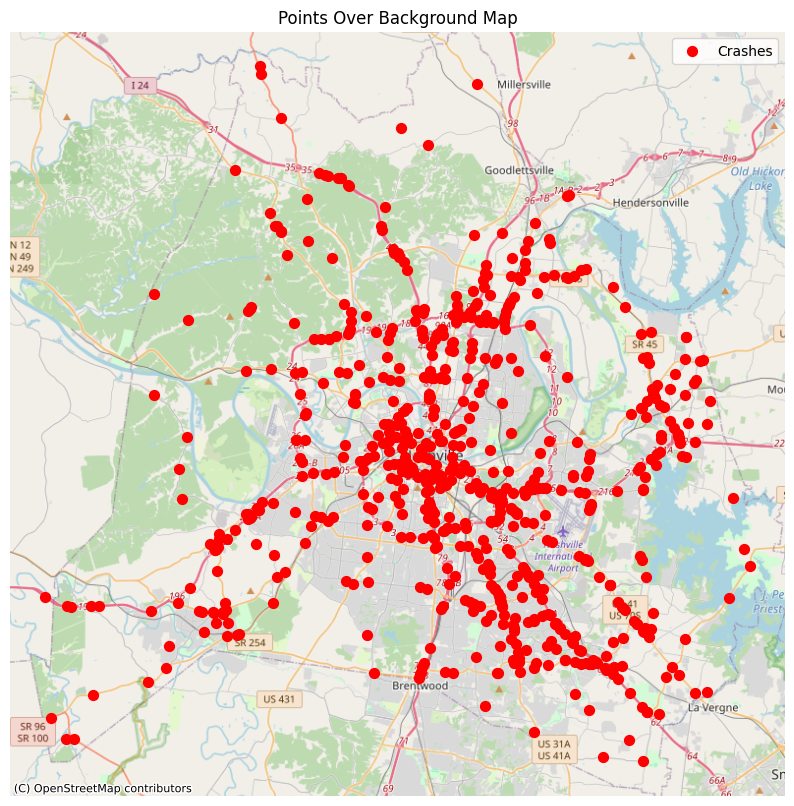

In [3]:
gdf = gpd.GeoDataFrame(
    crash_df,
    geometry=gpd.points_from_xy(crash_df.LONGITUD, crash_df.LATITUDE),
    crs="EPSG:4326")

gdf_web_mercator = gdf.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(10, 10))

gdf_web_mercator.plot(ax=ax, marker='o', color='red', markersize=50, label='Crashes')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Points Over Background Map")
plt.legend()
plt.show()

# Data Manipulation

### Read in precinct shape data, merge with crash data to make a new column for precinct

In [4]:
from shapely.geometry import Point
from pathlib import Path


precincts_map = gpd.read_file("precinct_zip.zip")


geometry = [Point(xy) for xy in zip(crash_df['LONGITUD'], crash_df['LATITUDE'])]
crashes_gdf = gpd.GeoDataFrame(crash_df, geometry=geometry)

# epsg=4326 reads lat-lon
crashes_gdf.set_crs(epsg=4326, inplace=True)
precincts_map = precincts_map.to_crs(epsg=4326)

# perform spatial join on shape data and crash data
precinct_df = gpd.sjoin(crashes_gdf, precincts_map, how='left', predicate='within')


In [5]:
precinct_df.head()

,DAY_WEEK,CITY,RAIL,MAN_COLL,LATITUDE,WEATHER1,HARM_EV,MINUTE,WEATHER2,HOSP_HR,...,VE_FORMS,NHS,ARR_MIN,LONGITUD,DAY,HOUR,geometry,index_right,PrecinctNa,GLOBALID
0,6,1760,0000000,0,36.177206,1,8,35,0,99,...,1,0,99,-86.753983,2,17,POINT (-86.75398 36.17721),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
1,2,1760,0000000,0,36.216794,2,8,30,0,99,...,1,0,99,-86.728900,5,17,POINT (-86.7289 36.21679),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
2,4,1760,0000000,0,36.196736,1,53,40,0,99,...,1,0,99,-86.828469,14,8,POINT (-86.82847 36.19674),2.0,NORTH,fc925a5e-2a0b-4b5e-a3f5-25d3c38034f3
3,7,1760,0000000,0,36.165511,1,42,0,0,99,...,1,0,99,-86.733536,14,3,POINT (-86.73354 36.16551),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
4,2,1760,0000000,0,36.057653,2,53,40,0,88,...,1,0,99,-86.691097,26,22,POINT (-86.6911 36.05765),4.0,SOUTHEAST,29f1598c-0572-465e-9245-610f6f4da1ce


In [6]:
precinct_df = precinct_df.rename(columns = {"PrecinctNa": "precinct"})

In [7]:
precinct_df[precinct_df['precinct'].isna()]

,DAY_WEEK,CITY,RAIL,MAN_COLL,LATITUDE,WEATHER1,HARM_EV,MINUTE,WEATHER2,HOSP_HR,...,VE_FORMS,NHS,ARR_MIN,LONGITUD,DAY,HOUR,geometry,index_right,precinct,GLOBALID
147,5,1760,0000000,7,36.082542,2,12,20,0,99,...,3,1,99,-87.044678,27,17,POINT (-87.04468 36.08254),NaN,NaN,NaN


The only na value from spatial join, one point that falls just out the modern boundary for Nashville so we'll drop that point

In [8]:
precinct_df = precinct_df.dropna(subset=['precinct'])
precinct_df

,DAY_WEEK,CITY,RAIL,MAN_COLL,LATITUDE,WEATHER1,HARM_EV,MINUTE,WEATHER2,HOSP_HR,...,VE_FORMS,NHS,ARR_MIN,LONGITUD,DAY,HOUR,geometry,index_right,precinct,GLOBALID
0,6,1760,0000000,0,36.177206,1,8,35,0,99,...,1,0,99,-86.753983,2,17,POINT (-86.75398 36.17721),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
1,2,1760,0000000,0,36.216794,2,8,30,0,99,...,1,0,99,-86.728900,5,17,POINT (-86.7289 36.21679),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
2,4,1760,0000000,0,36.196736,1,53,40,0,99,...,1,0,99,-86.828469,14,8,POINT (-86.82847 36.19674),2.0,NORTH,fc925a5e-2a0b-4b5e-a3f5-25d3c38034f3
3,7,1760,0000000,0,36.165511,1,42,0,0,99,...,1,0,99,-86.733536,14,3,POINT (-86.73354 36.16551),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
4,2,1760,0000000,0,36.057653,2,53,40,0,88,...,1,0,99,-86.691097,26,22,POINT (-86.6911 36.05765),4.0,SOUTHEAST,29f1598c-0572-465e-9245-610f6f4da1ce
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,7,1760,0000000,0,36.139911,5,24,11,0,8,...,1,1,33,-86.727811,28,8,POINT (-86.72781 36.13991),7.0,HERMITAGE,3c8dbffb-01f5-4852-94d8-efcfb93b8f11
703,1,1760,0000000,6,36.151800,2,12,3,0,11,...,2,1,16,-86.771250,29,10,POINT (-86.77125 36.1518),8.0,CENTRAL,bd3522ab-ee43-4c13-81a4-20b6081156be
704,7,1760,0000000,0,36.049039,10,8,24,0,14,...,1,1,46,-86.652550,21,13,POINT (-86.65255 36.04904),4.0,SOUTHEAST,29f1598c-0572-465e-9245-610f6f4da1ce
705,6,1760,0000000,6,36.184889,1,12,10,0,17,...,2,1,17,-86.773681,27,17,POINT (-86.77368 36.18489),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc


### Filter out NA values for hour and day of week before creating time segment variable

In [9]:
# FARS dataset usually records unknown hours as 99, so we drop those
precinct_df = precinct_df[precinct_df['HOUR'] < 24]

# FARS DAY_WEEK maps 1=Sunday, 2=Monday...7=Saturday
# We can map it to match 0-6 as Mon-Sun 
day_map = {2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 1: 6}
precinct_df['WEEK_DAY'] = precinct_df['DAY_WEEK'].map(day_map)

c:\Users\rache\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [10]:
# drop unnecessary columns
precinct_df = precinct_df.drop(columns={"DAY_WEEK", "geometry", "index_right", "GLOBALID"})
precinct_df

,CITY,RAIL,MAN_COLL,LATITUDE,WEATHER1,HARM_EV,MINUTE,WEATHER2,HOSP_HR,WEATHER,...,SP_JUR,HOSP_MN,VE_FORMS,NHS,ARR_MIN,LONGITUD,DAY,HOUR,precinct,WEEK_DAY
0,1760,0000000,0,36.177206,1,8,35,0,99,1,...,0,99,1,0,99,-86.753983,2,17,EAST,4
1,1760,0000000,0,36.216794,2,8,30,0,99,2,...,0,99,1,0,99,-86.728900,5,17,EAST,0
2,1760,0000000,0,36.196736,1,53,40,0,99,1,...,0,99,1,0,99,-86.828469,14,8,NORTH,2
3,1760,0000000,0,36.165511,1,42,0,0,99,1,...,0,99,1,0,99,-86.733536,14,3,EAST,5
4,1760,0000000,0,36.057653,2,53,40,0,88,2,...,0,88,1,0,99,-86.691097,26,22,SOUTHEAST,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,1760,0000000,0,36.139911,5,24,11,0,8,5,...,0,59,1,1,33,-86.727811,28,8,HERMITAGE,5
703,1760,0000000,6,36.151800,2,12,3,0,11,2,...,0,0,2,1,16,-86.771250,29,10,CENTRAL,6
704,1760,0000000,0,36.049039,10,8,24,0,14,10,...,0,20,1,1,46,-86.652550,21,13,SOUTHEAST,5
705,1760,0000000,6,36.184889,1,12,10,0,17,1,...,0,36,2,1,17,-86.773681,27,17,EAST,4


## Create Time Segment Variable

In [11]:
# create the mapping for time segments
segment_map = {
    0: 'Late Night', 1: 'Late Night', 2: 'Late Night', 3: 'Late Night',
    4: 'Early Morning', 5: 'Early Morning', 6: 'Early Morning', 7: 'Early Morning',
    8: 'Morning', 9: 'Morning', 10: 'Morning', 11: 'Morning',
    12: 'Afternoon', 13: 'Afternoon', 14: 'Afternoon', 15: 'Afternoon',
    16: 'Evening', 17: 'Evening', 18: 'Evening', 19: 'Evening',
    20: 'Night', 21: 'Night', 22: 'Night', 23: 'Night'
}

# apply to the dataframe
precinct_df['time_segment'] = precinct_df['HOUR'].map(segment_map)

In [12]:
precinct_df[["HOUR", "time_segment"]]

,HOUR,time_segment
0,17,Evening
1,17,Evening
2,8,Morning
3,3,Late Night
4,22,Night
...,...,...
702,8,Morning
703,10,Morning
704,13,Afternoon
705,17,Evening


In [13]:
# add back date column

precinct_df['DATE'] = pd.to_datetime(precinct_df[['YEAR', 'MONTH', 'DAY']])
precinct_df.head()

,CITY,RAIL,MAN_COLL,LATITUDE,WEATHER1,HARM_EV,MINUTE,WEATHER2,HOSP_HR,WEATHER,...,VE_FORMS,NHS,ARR_MIN,LONGITUD,DAY,HOUR,precinct,WEEK_DAY,time_segment,DATE
0,1760,0000000,0,36.177206,1,8,35,0,99,1,...,1,0,99,-86.753983,2,17,EAST,4,Evening,2009-01-02
1,1760,0000000,0,36.216794,2,8,30,0,99,2,...,1,0,99,-86.728900,5,17,EAST,0,Evening,2009-01-05
2,1760,0000000,0,36.196736,1,53,40,0,99,1,...,1,0,99,-86.828469,14,8,NORTH,2,Morning,2009-01-14
3,1760,0000000,0,36.165511,1,42,0,0,99,1,...,1,0,99,-86.733536,14,3,EAST,5,Late Night,2009-02-14
4,1760,0000000,0,36.057653,2,53,40,0,88,2,...,1,0,99,-86.691097,26,22,SOUTHEAST,0,Night,2009-01-26


## Inflate the data with zero values

Our fatal crash data only contains observations of crashes. In order to create a predictive model that predicts whether a crash occurs (0/1 binary outcome), we must have data points for occurrences of both crashes and no crashes. To get the occurrences of no crashes, we inflate our dataset to include all possible time segments across each precinct within our time period. 

In [14]:
import itertools
# generate all dates between 2009 to 2019
all_dates = pd.date_range(start='2009-01-01', end='2019-12-31', freq='D')

# time segments and precincts, so each precinct gets 0 values for every time segment at least
segments = ['Late Night', 'Early Morning', 'Morning', 'Afternoon', 'Evening', 'Night']
precincts = precinct_df['precinct'].unique() 

# create the cartesian product
master_grid = pd.DataFrame(list(itertools.product(all_dates, segments, precincts)), 
                           columns=['DATE', 'time_segment', 'precinct'])

In [15]:
master_grid['WEEK_DAY'] = master_grid['DATE'].dt.day_name()

In [16]:
precinct_df['FATAL_CRASH'] = 1

crash_counts = precinct_df.groupby(['DATE', 'time_segment', 'precinct'])['FATAL_CRASH'].sum().reset_index()

crash_counts

,DATE,time_segment,precinct,FATAL_CRASH
0,2009-01-02,Evening,EAST,1
1,2009-01-05,Evening,EAST,1
2,2009-01-14,Morning,NORTH,1
3,2009-01-24,Late Night,CENTRAL,1
4,2009-01-26,Night,SOUTHEAST,1
...,...,...,...,...
683,2019-12-21,Afternoon,SOUTHEAST,1
684,2019-12-26,Afternoon,NORTH,1
685,2019-12-27,Evening,EAST,1
686,2019-12-28,Morning,HERMITAGE,1


In [17]:
# left join master grid w crash df
inflated_df = pd.merge(master_grid, crash_counts, on=['DATE', 'time_segment', 'precinct'], how='left')

# fill gaps w 0
inflated_df['FATAL_CRASH'] = inflated_df['FATAL_CRASH'].fillna(0)

Check if there were any cases of more than 1 crash for a specific time segment in the same precinct:

In [18]:
inflated_df[inflated_df['FATAL_CRASH']>1]

,DATE,time_segment,precinct,WEEK_DAY,FATAL_CRASH
182459,2018-04-02,Night,SOUTHEAST,Monday,2.0


In [19]:
# change singular case of 2 crashes to binary outcome
inflated_df['FATAL_CRASH'] = (inflated_df['FATAL_CRASH'] >= 1).astype(int)

In [20]:
# add back month and year columns
inflated_df['MONTH'] = inflated_df['DATE'].dt.month
inflated_df['YEAR'] = inflated_df['DATE'].dt.year

In [21]:
inflated_df

,DATE,time_segment,precinct,WEEK_DAY,FATAL_CRASH,MONTH,YEAR
0,2009-01-01,Late Night,EAST,Thursday,0,1,2009
1,2009-01-01,Late Night,NORTH,Thursday,0,1,2009
2,2009-01-01,Late Night,SOUTHEAST,Thursday,0,1,2009
3,2009-01-01,Late Night,MIDTOWN HILLS,Thursday,0,1,2009
4,2009-01-01,Late Night,CENTRAL,Thursday,0,1,2009
...,...,...,...,...,...,...,...
216913,2019-12-31,Night,CENTRAL,Tuesday,0,12,2019
216914,2019-12-31,Night,MADISON,Tuesday,0,12,2019
216915,2019-12-31,Night,SOUTH,Tuesday,0,12,2019
216916,2019-12-31,Night,WEST,Tuesday,0,12,2019


## Filter data to include exact same dates as the SOPP data

In [22]:
inflated_df = inflated_df[(inflated_df['DATE']>= "2010-01-01") &( inflated_df['DATE']<= "2019-03-24")]

### Create Month Name column for ease of interpretation in results

In [23]:
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}


inflated_df['MONTH_NAME'] = inflated_df['MONTH'].map(month_map)


C:\Users\rache\AppData\Local\Temp\ipykernel_20208\2187251782.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inflated_df['MONTH_NAME'] = inflated_df['MONTH'].map(month_map)


## Save final clean csv to github to be used for modeling

In [24]:
inflated_df.to_csv("crash_inflated.csv")